In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KernelDensity
from scipy import stats

from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter


import time

from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'normal'


In [2]:
K2C = -273.15

In [3]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'daiys'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def weighted(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

In [4]:
def compute_pdf(dataset, ranges):
    

    m1, m2 = dataset['sst'].values, dataset['tp'].values

    #set ranges same for all 
    [xmin, xmax, ymin, ymax] = ranges


    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    values = np.vstack([m1, m2])
    kernel = stats.gaussian_kde(values, bw_method = 'silverman')
    Z = np.reshape(kernel(positions).T, X.shape)

    return Z

### 2023

In [5]:
#import tp: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp23 =  decode_time(fp).sel(time = slice('2023-01', '2023-12'), lat = slice(20,-20), lon = slice(130, 150))
tp23 = tp23.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


0.7024960517883301


In [6]:
#import sst: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst23 =  decode_time(fp).sel(time = slice('2023-01', '2023-12'), lat = slice(20,-20), lon = slice(130, 150))
sst23 = sst23.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


0.8237292766571045


In [7]:
df23 = pd.DataFrame({
    'sst': sst23['sst'].values.flatten(),
    'tp': tp23['tp'].values.flatten()
}).dropna()

### 2022

In [8]:
#import tp: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp22 =  decode_time(fp).sel(time = slice('2022-01', '2022-12'), lat = slice(20,-20), lon = slice(130, 150))
tp22 = tp22.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


0.4877779483795166


In [9]:
#import sst: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst22 =  decode_time(fp).sel(time = slice('2022-01', '2022-12'), lat = slice(20,-20), lon = slice(130, 150))
sst22 = sst22.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


0.49788689613342285


In [10]:
df22 = pd.DataFrame({
    'sst': sst22['sst'].values.flatten(),
    'tp': tp22['tp'].values.flatten()
}).dropna()

### Clim

In [11]:
#import tp: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tpclim =  decode_time(fp).sel(time = slice('1991-01', '2020-12'), lat = slice(20,-20), lon = slice(130, 150))
tpclim = tpclim.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


8.065205097198486


In [12]:
#import sst: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sstclim =  decode_time(fp).sel(time = slice('1991-01', '2020-12'), lat = slice(20,-20), lon = slice(130, 150))
sstclim = sstclim.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


9.219880104064941


In [13]:
dfclim = pd.DataFrame({
    'sst': sstclim['sst'].values.flatten()+K2C,
    'tp': tpclim['tp'].values.flatten()
}).dropna()

In [14]:
#import tp: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tpclim =  decode_time(fp).sel(time = slice('1991-01', '2020-12'), lat = slice(20,-20), lon = slice(150, 280))
tpclim = tpclim.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


7.963045358657837


In [15]:
#import sst: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sstclim =  decode_time(fp).sel(time = slice('1991-01', '2020-12'), lat = slice(20,-20), lon = slice(150, 280))
sstclim = sstclim.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


6.374550819396973


In [16]:
dfclimE = pd.DataFrame({
    'sst': sstclim['sst'].values.flatten()+K2C,
    'tp': tpclim['tp'].values.flatten()
}).dropna()

In [17]:
#import tp: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tpclim =  decode_time(fp).sel(time = slice('1991-01', '2020-12'), lat = slice(20,-20), lon = slice(130, 280))
tpclim = tpclim.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


7.914961576461792


In [18]:
#import sst: 
t0 = time.time()

#Coarsen
coarsen_factor = 20

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sstclim =  decode_time(fp).sel(time = slice('1991-01', '2020-12'), lat = slice(20,-20), lon = slice(130, 280))
sstclim = sstclim.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
print(time.time()-t0)


6.333165407180786


In [19]:
dfclimA = pd.DataFrame({
    'sst': sstclim['sst'].values.flatten()+K2C,
    'tp': tpclim['tp'].values.flatten()
}).dropna()

In [20]:
#set ranges of computing the pdf same for all
m1, m2 = dfclim['sst'].values, dfclim['tp'].values
xmin = 295-273.15#m1.min()
xmax = 305-273.15#m1.max()
ymin = m2.min()
ymax = m2.max()
ranges = [xmin, xmax, ymin, ymax]


t0 = time.time()
Zclim = compute_pdf(dfclim, ranges)
print(time.time()-t0)

t0 = time.time()
ZclimE = compute_pdf(dfclimE, ranges)
print(time.time()-t0)

t0 = time.time()
ZclimA = compute_pdf(dfclimA, ranges)
print(time.time()-t0)


1.332205057144165
9.81735110282898
11.53995943069458


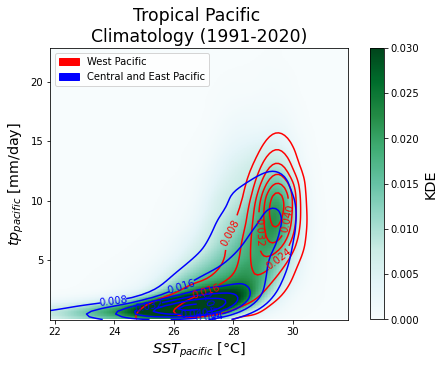

In [22]:
fig, ax1 = plt.subplots(1, 1, figsize = (8,5))


CS1 = ax1.contour((Zclim).T, colors = 'r',
            extent=[xmin, xmax, ymin, ymax])


CS2 = ax1.contour((ZclimE).T, colors = 'b',
            extent=[xmin, xmax, ymin, ymax])

cb = ax1.imshow(np.rot90((ZclimA)),
                  cmap = 'BuGn', 
                  vmin = 0.00, vmax = 0.03,
                  extent=[xmin, xmax, ymin, ymax], 
                   aspect = .4)

ax1.clabel(CS1, inline=1, fontsize=10)
ax1.clabel(CS2, inline=1, fontsize=10)


#ax1.clabel(CS, inline=1, fontsize=10)

ax1.set_ylabel('$tp_{pacific}$ [mm/day]')
ax1.set_xlabel(r'$SST_{pacific}$ [°C]')
ax1.set_title('Tropical Pacific \nClimatology (1991-2020)')

# Create custom legend patches
west_pacific_patch = Patch(color='r', label='West Pacific')
central_east_pacific_patch = Patch(color='b', label='Central and East Pacific')

# Add the custom legend to the plot
ax1.legend(handles=[west_pacific_patch, central_east_pacific_patch], loc = 'upper left')


fig.colorbar(cb, label = 'KDE')


In [23]:
import time
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the function compute_pdf() and decode_time() used in your code

# Parameters
coarsen_factor = 20
year_pairs = [ (1996, 1997), (2014, 2015), (2022, 2023)]
data_path_tp = '/data/jmex/ERA5/monthly/era5_tp.nc'
data_path_sst = '/data/jmex/ERA5/monthly/era5_sst.nc'
xmin = 295+K2C
xmax = 305+K2C

# Initialize storage for PDFs
pdfs = []

for year1, year2 in year_pairs:
    # Load and process data for the first year
    t0 = time.time()
    tp1 = decode_time(data_path_tp).sel(time=slice(f'{year1}-01', f'{year1}-12'), lat=slice(20, -20), lon=slice(130, 150))
    tp1 = tp1.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
    sst1 = decode_time(data_path_sst).sel(time=slice(f'{year1}-01', f'{year1}-12'), lat=slice(20, -20), lon=slice(130, 150))
    sst1 = sst1.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
    df1 = pd.DataFrame({'sst': sst1['sst'].values.flatten()+K2C, 'tp': tp1['tp'].values.flatten()}).dropna()
    print(f'Processed year {year1} in {time.time()-t0} seconds')

    # Load and process data for the second year
    t0 = time.time()
    tp2 = decode_time(data_path_tp).sel(time=slice(f'{year2}-01', f'{year2}-12'), lat=slice(20, -20), lon=slice(130, 150))
    tp2 = tp2.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
    sst2 = decode_time(data_path_sst).sel(time=slice(f'{year2}-01', f'{year2}-12'), lat=slice(20, -20), lon=slice(130, 150))
    sst2 = sst2.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()
    df2 = pd.DataFrame({'sst': sst2['sst'].values.flatten()+K2C, 'tp': tp2['tp'].values.flatten()}).dropna()
    print(f'Processed year {year2} in {time.time()-t0} seconds')

    # Compute PDFs
    t0 = time.time()
    ranges = [xmin, xmax, df1['tp'].values.min(), df1['tp'].values.max()]
    pdf1 = compute_pdf(df1, ranges)
    pdf2 = compute_pdf(df2, ranges)
    pdfs.append((pdf1, pdf2))
    print(f'Computed PDFs for {year1} and {year2} in {time.time()-t0} seconds')

Processed year 1996 in 0.9892725944519043 seconds
Processed year 1997 in 0.8391404151916504 seconds
Computed PDFs for 1996 and 1997 in 0.13149046897888184 seconds
Processed year 2014 in 0.6822531223297119 seconds
Processed year 2015 in 0.5543396472930908 seconds
Computed PDFs for 2014 and 2015 in 0.07570815086364746 seconds
Processed year 2022 in 0.563683032989502 seconds
Processed year 2023 in 0.5552012920379639 seconds
Computed PDFs for 2022 and 2023 in 0.07575774192810059 seconds


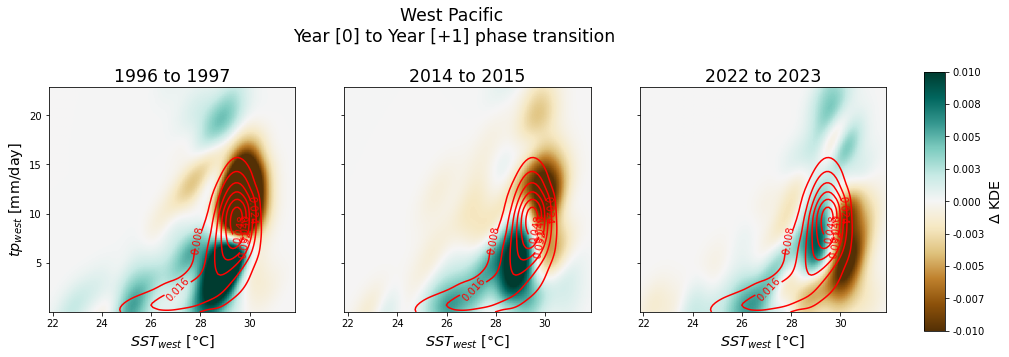

In [25]:
# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15,9), sharey=True)

for i, ((pdf1, pdf2), (year1, year2)) in enumerate(zip(pdfs, year_pairs)):

    ax = axes[i]
    
    
    CS = ax.contour(Zclim.T, colors='r', extent=[xmin, xmax, ymin, ymax])
    
    cb = ax.imshow(np.rot90(pdf2 - pdf1),
                   cmap='BrBG', vmin=-0.01, vmax=0.01,
                   extent=[xmin, xmax, ymin, ymax], 
                  aspect = 0.4)
    
    ax.clabel(CS, inline=1, fontsize=10)
    ax.set_title(f'{year1} to {year2}')
    
    
    ax.set_xlabel(r'$SST_{west}$ [°C]', fontweight = 'normal')
axes[0].set_ylabel(r'$tp_{west}$ [mm/day]', fontweight = 'normal')
# Add colorbar
cbar_ax = fig.add_axes([0.935, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
cbar = fig.colorbar(cb, cax=cbar_ax)
cbar.set_label(r'$\Delta$ KDE')
# Define a custom formatter
formatter = FuncFormatter(lambda x, pos: f'{x:.3f}')

# Set the formatter for the colorbar
cbar.ax.yaxis.set_major_formatter(formatter)

plt.suptitle('West Pacific \nYear [0] to Year [+1] phase transition',
             fontweight='normal', fontsize='xx-large', y=0.8)

#plt.tight_layout()
plt.show()